In [2]:
!pip install tensorcircuit
!pip install qibo

In [2]:
!pip install numpy==1.26.4

  Using cached numpy-1.26.4-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (61 kB)
Using cached numpy-1.26.4-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (18.0 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
qibo 0.3.3 requires numpy<3.0.0,>=2.0.0, but you have numpy 1.26.4 which is incompatible.
shap 0.52.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
xarray-einstats 0.10.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
tifffile 2026.4.11 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
jaxlib 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
opencv-python-headless 4.13.0.92 requires n

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import time

import tensorcircuit as tc
import tensorflow as tf

from qibo.hamiltonians import TFIM


TypeError: reshape() got an unexpected keyword argument 'newshape'

TensorCircuit internamente usa tensor networks

Resolver el modelo de Ising cuántico (TFIM) usando: VQE (Variational Quantum Eigensolver), buscando: los parámetros θ que minimizan la energía

In [ ]:
# zz gate matrix to be utilized
zz = np.kron(tc.gates._z_matrix, tc.gates._z_matrix)
print(zz)

In [3]:
def tfi_energy(c: tc.Circuit, j: float = 1.0, h: float = -1.0):
    e = 0.0
    n = c._nqubits
    for i in range(n):
        e += h * c.expectation((tc.gates.x(), [i]))  # <X_i>
    for i in range(n - 1):  # OBC
        e += j * c.expectation(
            (tc.gates.z(), [i]), (tc.gates.z(), [(i + 1) % n])
        )  # <Z_iZ_{i+1}>
    return tc.backend.real(e)

In [4]:
def vqe_tfim(param, n, nlayers):
    c = tc.Circuit(n)

    paramc = tc.backend.cast(param, tc.dtypestr)

    for i in range(n):
        c.H(i)

    for j in range(nlayers):
        for i in range(n - 1):
            c.exp1(i, i + 1, unitary=zz, theta=paramc[2 * j, i])

        for i in range(n):
            c.rx(i, theta=paramc[2 * j + 1, i])

    return tfi_energy(c)


In [7]:

import time
import numpy as np
import tensorflow as tf


def train_step_tf(n, nlayers, maxiter=2000, exact_energy=None):

    param = tf.Variable(
        initial_value=tf.random.normal(
            shape=[nlayers * 2, n],
            stddev=0.1,
            dtype=getattr(tf, tc.rdtypestr)
        )
    )

    opt = tf.keras.optimizers.Adam(1e-2)

    energy_history = []

    start = time.time()

    for i in range(maxiter):

        with tf.GradientTape() as tape:
            e = vqe_tfim(param, n, nlayers)

        grad = tape.gradient(e, param)
        opt.apply_gradients([(grad, param)])

        energy_history.append(e.numpy())

        if i % 200 == 0:
            print("iter", i, "energy", e.numpy())

    elapsed = time.time() - start

    final_energy = energy_history[-1]

    error = abs(final_energy - exact_energy)

    return final_energy, error, elapsed, energy_history


import matplotlib.pyplot as plt


def experiment():

    L_list = [4, 6, 8, 10, 12]

    layers = 3

    times = []
    errors = []
    sizes = []

    for L in L_list:

        print(f"\nL = {L}")

        # energía exacta (pequeños L)
        H = TFIM(L, h=1.0)
        exact = np.real(H.eigenvalues()[0])

        _, error, t, _ = train_step_tf(
            n=L,
            nlayers=layers,
            maxiter=1000,
            exact_energy=exact
        )

        sizes.append(L)
        times.append(t)
        errors.append(error)

    # =========================
    # PARETO FRONT
    # =========================

    plt.figure(figsize=(7,5))

    plt.loglog(
        times,
        errors,
        'o-',
        label="VQE TensorFlow"
    )

    plt.xlabel("Tiempo CPU (s)")
    plt.ylabel("Error energético |E - E0|")
    plt.title("Frontera de Pareto")
    plt.grid()
    plt.legend()

    plt.show()


    # =========================
    # ESCALADO
    # =========================

    plt.figure(figsize=(7,5))

    plt.plot(
        sizes,
        times,
        'o-',
        label="VQE TensorFlow"
    )

    plt.xlabel("L")
    plt.ylabel("Tiempo CPU (s)")
    plt.title("Escalado con tamaño")
    plt.grid()
    plt.legend()

    plt.show()


if __name__ == "__main__":
    experiment()


L = 4
iter 0 energy -3.918466
iter 200 energy -4.728539
iter 400 energy -4.7581778
iter 600 energy -4.7583323
iter 800 energy -4.7584987

L = 6
iter 0 energy -5.33727
iter 200 energy -7.1468587
iter 400 energy -7.2290626
iter 600 energy -7.250942
iter 800 energy -7.2874465

L = 8
iter 0 energy -7.7686934


KeyboardInterrupt: 

COMPARACIÓN

In [3]:
!pip install quimb

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.9/60.9 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 30.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 941.6/941.6 kB 49.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 254.4/254.4 kB 18.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 51.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.2/19.2 MB 68.7 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.4.6
    Uninstalling numpy-2.4.6:
      Successfully uninstalled numpy-2.4.6


In [1]:
import numpy as np
import matplotlib.pyplot as plt

import quimb as q
import quimb.tensor as qtn

import tensorcircuit as tc
import tensorflow as tf

tc.set_backend("tensorflow")
tc.set_dtype("complex64")

('complex64', 'float32')

In [2]:
def exact_energy_tf(L, j=1.0, h=1):
    H = qtn.MPO_ham_ising(L, j=j, bx=h).to_dense()
    eigs = np.linalg.eigvalsh(H)
    return np.min(eigs)

In [3]:
def dmrg_energy(L, j=1.0, bx=0.5, bond_dims=[8, 16, 32,64]):
    H = qtn.MPO_ham_ising(L, j=j, bx=bx)

    dmrg = qtn.DMRG2(
        H,
        bond_dims=bond_dims
    )

    dmrg.solve(verbosity=0, tol=1e-6)

    return dmrg.energy

In [13]:
def vqe_energy(param, L, nlayers, j=1.0, h=1.0):

    zz = np.kron(tc.gates._z_matrix, tc.gates._z_matrix)

    c = tc.Circuit(L)

    param = tc.backend.cast(param, tc.dtypestr)

    for i in range(L):
        c.H(i)

    for l in range(nlayers):
        for i in range(L - 1):
            c.exp1(i, i + 1, unitary=zz, theta=param[2*l, i])

        for i in range(L):
            c.rx(i, theta=param[2*l + 1, i])

    # energy
    e = 0.0
    for i in range(L):
        # Cambiamos h por h/2 para coincidir con espín-1/2
        e += -(h / 2.0) * c.expectation((tc.gates.x(), [i]))

    for i in range(L - 1):
        # Cambiamos j por j/4 para coincidir con espín-1/4
        e += -(j / 4.0) * c.expectation(
            (tc.gates.z(), [i]),
            (tc.gates.z(), [i + 1])
        )

    return tc.backend.real(e)


def train_vqe(L, nlayers=2, steps=300):

    param = tf.Variable(
        tf.random.normal([2*nlayers, L], stddev=0.1)
    )

    opt = tf.keras.optimizers.Adam(0.01)

    for i in range(steps):

        with tf.GradientTape() as tape:
            e = vqe_energy(param, L, nlayers)

        grad = tape.gradient(e, param)
        opt.apply_gradients([(grad, param)])

        if i % 100 == 0:
            print(f"VQE step {i}: energy = {e.numpy():.6f}")

    return float(e.numpy())

In [21]:
import time

def experiment():

    L_list = [4, 6,8,10]

    vqe_E = []
    dmrg_E = []
    exact_E = []

    times_vqe = []
    times_dmrg = []

    nlayers = 2

    for L in L_list:

        print("\n======================")
        print("L =", L)

        # -------- EXACTO --------
        if L <= 10:
            E_exact = exact_energy_tf(L)
        else:
            E_exact = np.nan

        # -------- DMRG --------
        start = time.time()

        E_dmrg = dmrg_energy(L)

        t_dmrg = time.time() - start

        # -------- VQE --------
        start = time.time()

        E_vqe = train_vqe(L, nlayers)

        t_vqe = time.time() - start



        exact_E.append(E_exact)
        dmrg_E.append(E_dmrg)
        vqe_E.append(E_vqe)

        times_dmrg.append(t_dmrg)
        times_vqe.append(t_vqe)

    return (
        L_list,
        vqe_E,
        dmrg_E,
        exact_E,
        times_vqe,
        times_dmrg,
    )

In [22]:
L_list, vqe_E, dmrg_E, exact_E, times_vqe, times_dmrg = experiment()


L = 4
VQE step 0: energy = -1.998427
VQE step 100: energy = -2.088948
VQE step 200: energy = -2.089463

L = 6
VQE step 0: energy = -2.877844
VQE step 100: energy = -3.148100
VQE step 200: energy = -3.150776

L = 8
VQE step 0: energy = -3.757743
VQE step 100: energy = -4.205117
VQE step 200: energy = -4.210031

L = 10
VQE step 0: energy = -4.856594
VQE step 100: energy = -5.264317
VQE step 200: energy = -5.267634


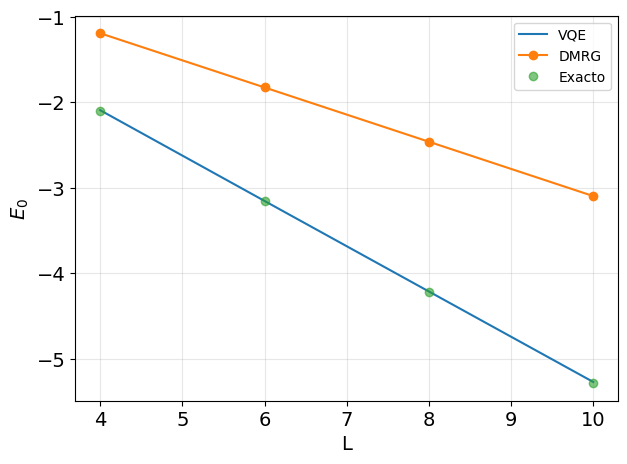

In [28]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(7,5))

plt.plot(L_list, vqe_E, '-', label="VQE")
plt.plot(L_list, dmrg_E, 'o-', label="DMRG")
plt.plot(L_list, exact_E, 'o', alpha=0.6,label="Exacto")

plt.xlabel("L",fontsize=14)
plt.ylabel(r"$E_0$",fontsize=14)

plt.grid(alpha=0.3)
plt.legend()
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

plt.show()

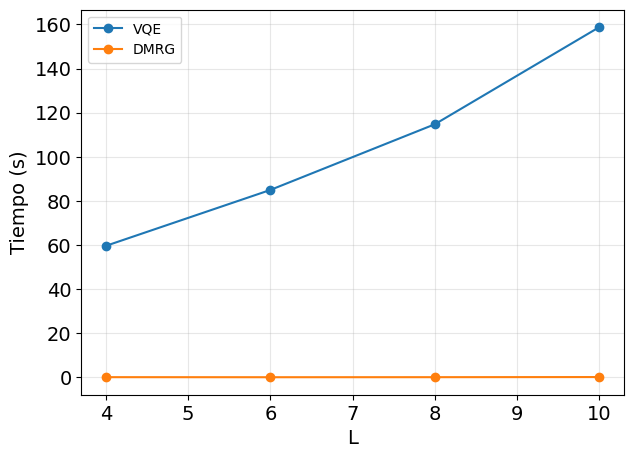

In [20]:
plt.figure(figsize=(7,5))

plt.plot(L_list, times_vqe, 'o-', label='VQE')
plt.plot(L_list, times_dmrg, 'o-', label='DMRG')

plt.xlabel('L',fontsize=14)
plt.ylabel('Tiempo (s)',fontsize=14)

plt.legend()
plt.grid(alpha=0.3)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

plt.show()